## Purpose:
Train and evaluate an XGBoost classifier to predict in-hospital mortality for ICU patients using SQL-engineered features from the MIMIC-III demo dataset. This notebook serves as the  proof-of-concept for Track 1 from raw database query to a trained, explainable ML model.

## Context:
The MIMIC-III demo contains ~100 ICU stays with a high mortality rate relative to the full dataset, creating a significant class imbalance. Standard accuracy metrics are misleading under these conditions, so this notebook uses AUROC as the primary evaluation metric and applies scale_pos_weight in XGBoost to compensate for the skewed class distribution.
All features are pulled directly from the SQL views built in sql/features.sql via tracks/sql_features.py — no feature engineering happens inside this notebook. The notebook's job is purely modeling: load features, handle imbalance, train, evaluate, and explain.
This notebook is intentionally scoped to the demo dataset as a pipeline prototype. Results should be interpreted as proof-of-concept only — production-quality performance requires the full MIMIC-III dataset (~46,000 ICU stays).

# Section 1 Imports

In [1]:
# Data handling
import pandas as pd
import numpy as np 

# Database
import sqlite3

# Model 
from xgboost import XGBClassifier

# Class imbalance 
from imblearn.over_sampling import SMOTE

# Sklearn utilities 
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import StandardScaler

# Explainability 
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Extras 
import warnings
from pathlib import Path
from scipy.stats import gaussian_kde

c:\Users\delga\anaconda3\envs\clinical-intelligence\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Section 2 Configuration 

In [2]:
# -- Setup path to mimic.db --
DB_PATH = Path("../db/mimic.db")

# -- Define target column --
TARGET = "died_in_hospital"

# -- Setup Random seeds for Reproducibility --
SEED = 42 
np.random.seed(SEED)

# -- Class Imbalance Placeholder --
SCALE_POS_WEIGHT = None 

# -- Supress any warnings --
warnings.filterwarnings("ignore")

# -- Plot Style -- 
sns.set_style("whitegrid")

# -- Sanity Check -- 
assert DB_PATH.exists(), f"Database not found at {DB_PATH}"
print(f"✅ Database found: {DB_PATH}")

✅ Database found: ..\db\mimic.db


# Section 3 Loading Features from the Database

In [3]:
# Connect to Database 
conn = sqlite3.connect(DB_PATH)

# Execute SQL file to create views in mimic.db
with open("../sql/features.sql") as f:
    sql = f.read()
conn.executescript(sql)

# Query the features from the databse 
v_features = pd.read_sql("SELECT * FROM v_features", conn)

# Query v_features view into a DataFrame
df = pd.read_sql("SELECT * FROM v_features", conn)

# Close connection
conn.close()

# Sanity checks
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (136, 89)
Columns: ['subject_id', 'hadm_id', 'icustay_id', 'gender', 'admission_type', 'insurance', 'ethnicity', 'dob', 'dod', 'intime', 'outtime', 'admittime', 'dischtime', 'icu_los_hours', 'hosp_los_days', 'age_at_admit', 'died_in_hospital', 'hr_mean_24h', 'hr_min_24h', 'hr_max_24h', 'sbp_mean_24h', 'sbp_min_24h', 'sbp_max_24h', 'spo2_mean_24h', 'spo2_min_24h', 'spo2_max_24h', 'resp_mean_24h', 'resp_min_24h', 'resp_max_24h', 'temp_mean_24h', 'temp_min_24h', 'temp_max_24h', 'gcs_mean_24h', 'gcs_min_24h', 'gcs_max_24h', 'n_vital_measurements_24h', 'hematocrit_mean_24h', 'hematocrit_min_24h', 'potassium_mean_24h', 'potassium_min_24h', 'potassium_max_24h', 'sodium_mean_24h', 'sodium_min_24h', 'sodium_max_24h', 'creatinine_mean_24h', 'creatinine_max_24h', 'chloride_mean_24h', 'bun_mean_24h', 'bun_max_24h', 'bicarb_mean_24h', 'bicarb_min_24h', 'anion_gap_mean_24h', 'anion_gap_max_24h', 'glucose_mean_24h', 'glucose_min_24h', 'glucose_max_24h', 'platelets_mean_24h', 'platelets_min_24h

,subject_id,hadm_id,icustay_id,gender,admission_type,insurance,ethnicity,dob,dod,intime,...,has_chf,has_diabetes,has_resp_failure,has_sepsis,has_anemia,has_cad,has_acidosis,n_diagnoses,n_prior_admissions,vasopressor_flag
0,10006,142345,206504,F,EMERGENCY,Medicare,BLACK/AFRICAN AMERICAN,2094-03-05,2165-08-12,2164-10-23 21:10:15,...,1,1,0,0,1,1,0,21,0,0
1,10011,105331,232110,F,EMERGENCY,Private,UNKNOWN/NOT SPECIFIED,2090-06-05,2126-08-28,2126-08-14 22:34:00,...,0,0,0,0,0,0,0,6,0,0
2,10013,165520,264446,F,EMERGENCY,Medicare,UNKNOWN/NOT SPECIFIED,2038-09-03,2125-10-07,2125-10-04 23:38:00,...,0,0,0,1,0,0,0,9,0,1
3,10017,199207,204881,F,EMERGENCY,Medicare,WHITE,2075-09-21,2152-09-12,2149-05-29 18:52:29,...,0,1,0,0,1,0,0,14,0,0
4,10019,177759,228977,M,EMERGENCY,Medicare,WHITE,2114-06-20,2163-05-15,2163-05-14 20:43:56,...,0,0,1,1,0,0,0,14,0,1


# Section 04 EDA

The goal is to understand your data before modeling, especially around the class imbalance issue in the Demo of MIMIC 3. 

**Part 1 — Class balance**
This is the most important thing to look at given what we know. We want to see how many patients died vs survived.

**Part 2 — Missing values**
XGBoost handles NaNs natively but we still want to know how many nulls exist per column.

**Part 3 — Feature distributions**
Pick a few clinically meaningful features from what you know about v_features — things like age_at_admit, icu_los_hours, creatinine_max_24h.

**Part 4 — Compute SCALE_POS_WEIGHT**


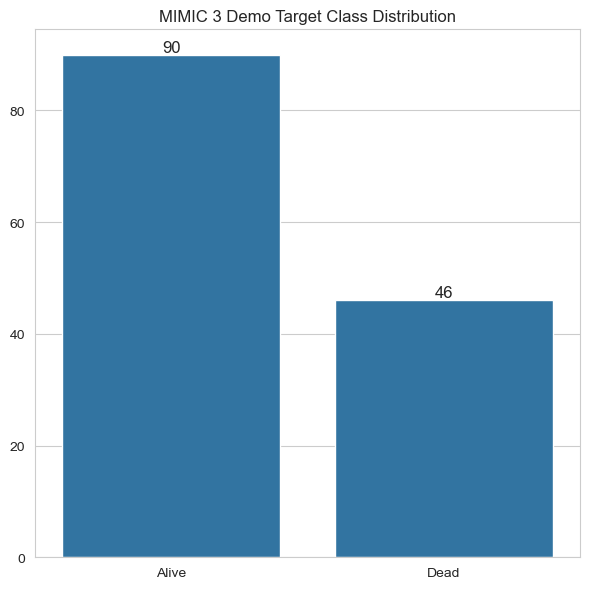

In [4]:
# Part 1


# -- View our class imbalance --
# Obtain counts of classes
target_counts = df['died_in_hospital'].value_counts()

# Store counts in a dictionary 
target_dist = {'Alive': target_counts.get(0), 'Dead': target_counts.get(1)}

# -- Create Visualization of class imablance as a barchart --
plt.figure(figsize=(6,6), facecolor='white') # Make Figure
ax = sns.barplot(target_dist) # Plot the bar chart
for bar in ax.patches:
    ax.annotate(
        str(int(bar.get_height())),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.title("MIMIC 3 Demo Target Class Distribution")
plt.tight_layout()
plt.show()

Columns with nulls: 59 / 89
hr_mean_24h                  4
hr_min_24h                   4
hr_max_24h                   4
sbp_mean_24h                32
sbp_min_24h                 32
sbp_max_24h                 32
spo2_mean_24h                4
spo2_min_24h                 4
spo2_max_24h                 4
resp_mean_24h                4
resp_min_24h                 4
resp_max_24h                 4
temp_mean_24h                7
temp_min_24h                 7
temp_max_24h                 7
gcs_mean_24h                 4
gcs_min_24h                  4
gcs_max_24h                  4
n_vital_measurements_24h     4
hematocrit_mean_24h          5
hematocrit_min_24h           5
potassium_mean_24h           3
potassium_min_24h            3
potassium_max_24h            3
sodium_mean_24h              3
sodium_min_24h               3
sodium_max_24h               3
creatinine_mean_24h          4
creatinine_max_24h           4
chloride_mean_24h            4
bun_mean_24h                 5
bun_max_24h

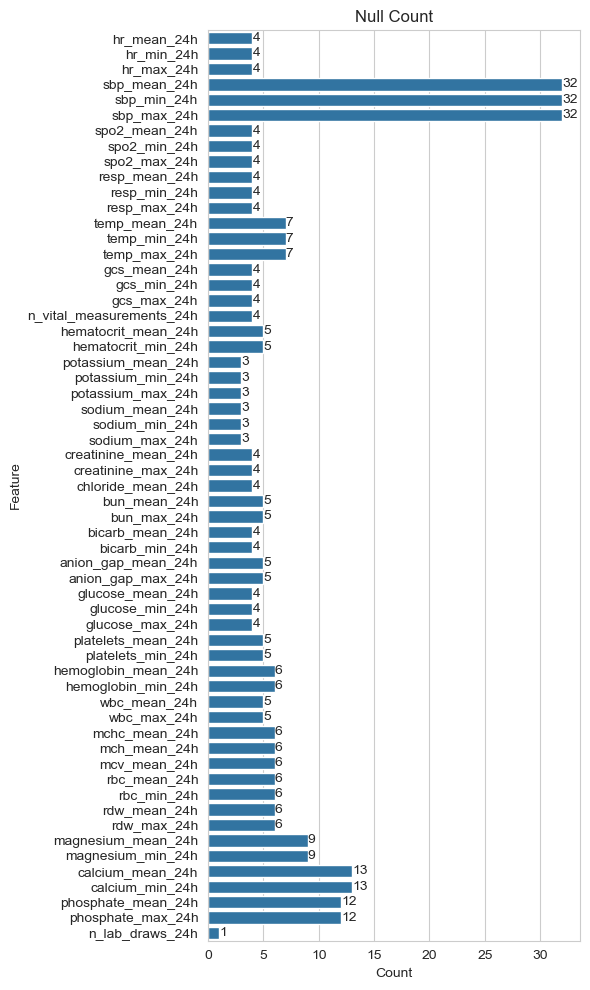

In [5]:
# Part 2

# -- Determine the null count for each column 
null_counts = df.isnull().sum().rename('null_count')
null_counts = null_counts[null_counts > 0] # Filter where we do have nulls

print(f"Columns with nulls: {len(null_counts)} / {df.shape[1]}")
print(null_counts)

if len(null_counts) == 0:
    print("✅ No null values found")
else:
    # Visualize the nulls 
    plt.figure(figsize=(6, 10), facecolor='white')
    ax = sns.barplot(x=null_counts.values, y=null_counts.index, orient='h')
    
    for bar in ax.patches:
        ax.annotate(
            str(int(bar.get_width())), # The count
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            ha='left',
            va='center',
            fontsize=10
        )

    plt.title("Null Count")
    plt.ylabel("Feature")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

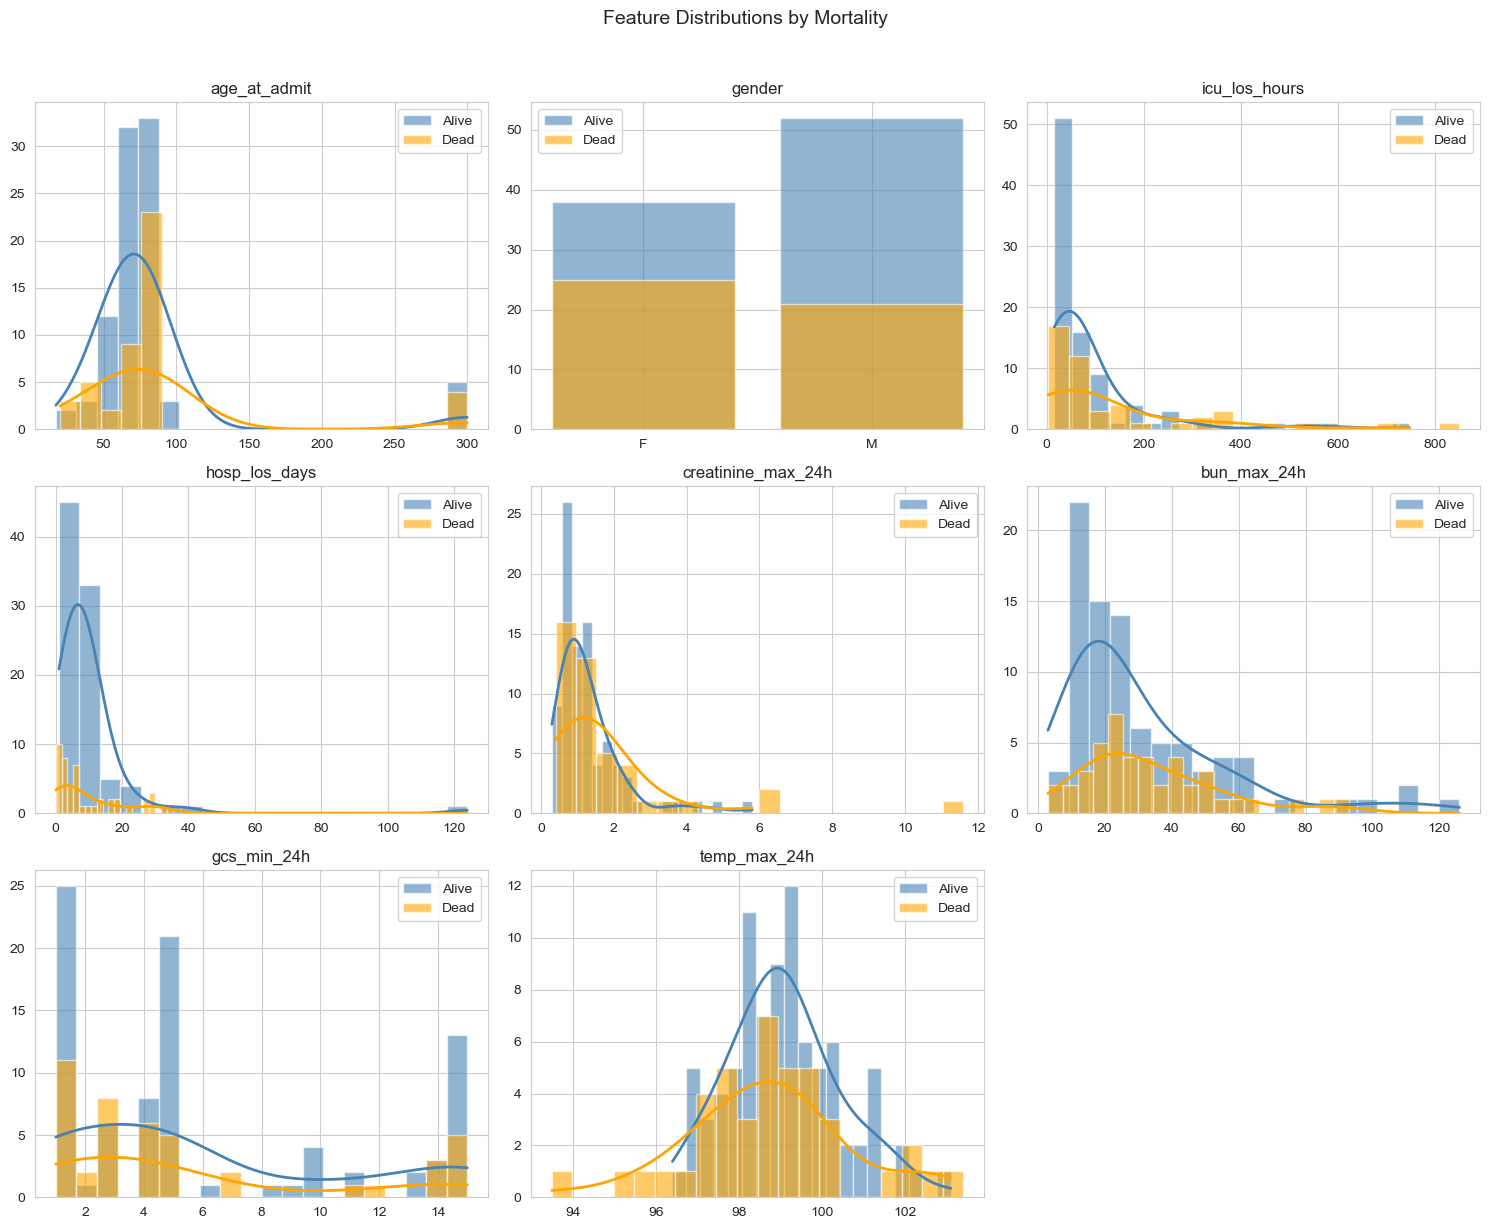

In [6]:
# Part 3 

# There are many features to plot but some features that can potentially tell a good story are kidney failure features. 
# In addition to this demographics also plays a major role
features_to_plot = [
    # -- Demographics --
    "age_at_admit", # Tell us patient age
    "gender", # Tells us patient gender
    
    # -- ICU Stay --
    "icu_los_hours", # ICU Stay in hours
    "hosp_los_days", # Total hospital stay
    
    # -- Lab Values -- 
    "creatinine_max_24h", # high creatinine signals kidney failure, strongly tied to mortality
    #"lactate_max_24h", # elevated lactate indicates poor oxygen delivery, a key sepsis marker
    "bun_max_24h", # blood urea nitrogen, another kidney function marker
    
    # -- Vital Signs -- 
    "gcs_min_24h", # Glasgow Coma Scale minimum, low scores mean reduced consciousness, highly predictive of death
    "temp_max_24h", # ever can indicate infection
]

df_plot = df.dropna(subset=['died_in_hospital']) 
df_plot['died_in_hospital'] = df_plot['died_in_hospital'].astype(int)

# -- Create plot grid --
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
# Iterate on desired features to plot 
for i, feature in enumerate(features_to_plot):
    df_clean = df_plot.dropna(subset=[feature])
    
    alive = df_clean[df_clean['died_in_hospital'] == 0]
    dead  = df_clean[df_clean['died_in_hospital'] == 1]
    
    ax = axes[i]
    
    if feature == 'gender':
        ax.bar(['F', 'M'], 
                [alive[feature].value_counts().get('F', 0), 
                alive[feature].value_counts().get('M', 0)], 
                alpha=0.6, label='Alive', color='steelblue')
        ax.bar(['F', 'M'], 
                [dead[feature].value_counts().get('F', 0), 
                dead[feature].value_counts().get('M', 0)], 
                alpha=0.6, label='Dead', color='orange')
    else:
        ax.hist(alive[feature], alpha=0.6, label='Alive', color='steelblue', bins=20)
        ax.hist(dead[feature],  alpha=0.6, label='Dead',  color='orange',    bins=20)
        # -- KDE --
        # Get the data for one class
        values_alive = alive[feature].dropna()
        values_dead = dead[feature].dropna()
        
        # Create KDE object
        kde_alive = gaussian_kde(values_alive)
        kde_dead = gaussian_kde(values_dead)
        
        # Create a range of x values spanning the data
        x_range_alive = np.linspace(values_alive.min(), values_alive.max(), 200)
        x_range_dead = np.linspace(values_dead.min(), values_alive.max(), 200)
        
        # Scale the KDE to match histogram counts
        ax.plot(x_range_alive, kde_alive(x_range_alive) * len(values_alive) * (values_alive.max() - values_alive.min()) / 20, 
                color='steelblue', linewidth=2)
        ax.plot(x_range_dead, kde_dead(x_range_dead) * len(values_dead) * (values_dead.max() - values_dead.min()) / 20, 
                color='orange', linewidth=2)
    ax.set_title(feature)
    ax.legend()

for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Mortality", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Clinical interpretation of each plot:

`age_at_admit`
Alive patients peak around 60-70 years. Dead patients spread further right toward 80-90+. Older patients have less physiological reserve fewer functional organs, more comorbidities, less ability to recover from critical illness. Age is one of the strongest predictors of ICU mortality.

`gcs_min_24h`
This one spreads left not right because, lower GCS is worse. Dead patients cluster at 2-4 (deeply unconscious, unresponsive) while alive patients peak at 14-15 (fully alert). GCS below 8 is clinically defined as a coma. This is likely a strong predictor for XGBoost.

`creatinine_max_24h`
Dead patients have a longer right tail beyond 4-6 mg/dL. Normal creatinine is 0.6-1.2 mg/dL. Severely elevated creatinine means the kidneys are failing and the body can't filter waste products, toxins accumulate, and multi-organ failure follows.

`bun_max_24h`
Similar story to creatinine where dead patients spread further right beyond 40-60 mg/dL. Normal BUN is 7-20 mg/dL. When both BUN and creatinine are elevated together it strongly suggests acute kidney injury which dramatically increases mortality risk.

`icu_los_hours`
This is the counterintuitive one. You might expect sicker patients who die to spend more time in the ICU — but the plot shows dead patients actually have shorter stays. Why? 

Two reasons Susppected Reasons:
Patients who die often deteriorate and pass away quickly, within the first 24-48 hours
Patients who survive long enough to recover naturally accumulate more ICU hours

`hosp_los_days`
Same story as ICU hours but at the hospital level. Dead patients cluster in the first 1-20 days. Survivors spread further right because they stay longer recovering before discharge.

`temp_max_24h`
Dead patients orange curve shifts slightly right toward higher temperatures. Fever above 38.3°C (101°F) indicates systemic infection, both strongly associated with ICU mortality. The separation here is subtle though. Temperature will most likely be a weak predictor compared to GCS or creatinine.

`gender`
Hard to draw strong conclusions from this plot alone. Males appear in higher numbers overall in both groups, which likely reflects the general ICU population demographics rather than gender being a strong mortality predictor. You'd need a normalized proportion chart to see a real gender effect.

**The big picture for XGBoost:**
The strongest suspected predictors in this order:

gcs_min_24h — clearest separation
creatinine_max_24h — strong right tail
bun_max_24h — kidney failure signal
age_at_admit — consistent rightward shift
temp_max_24h — subtle but present
icu_los_hours — present but counterintuitive
gender — weakest signal

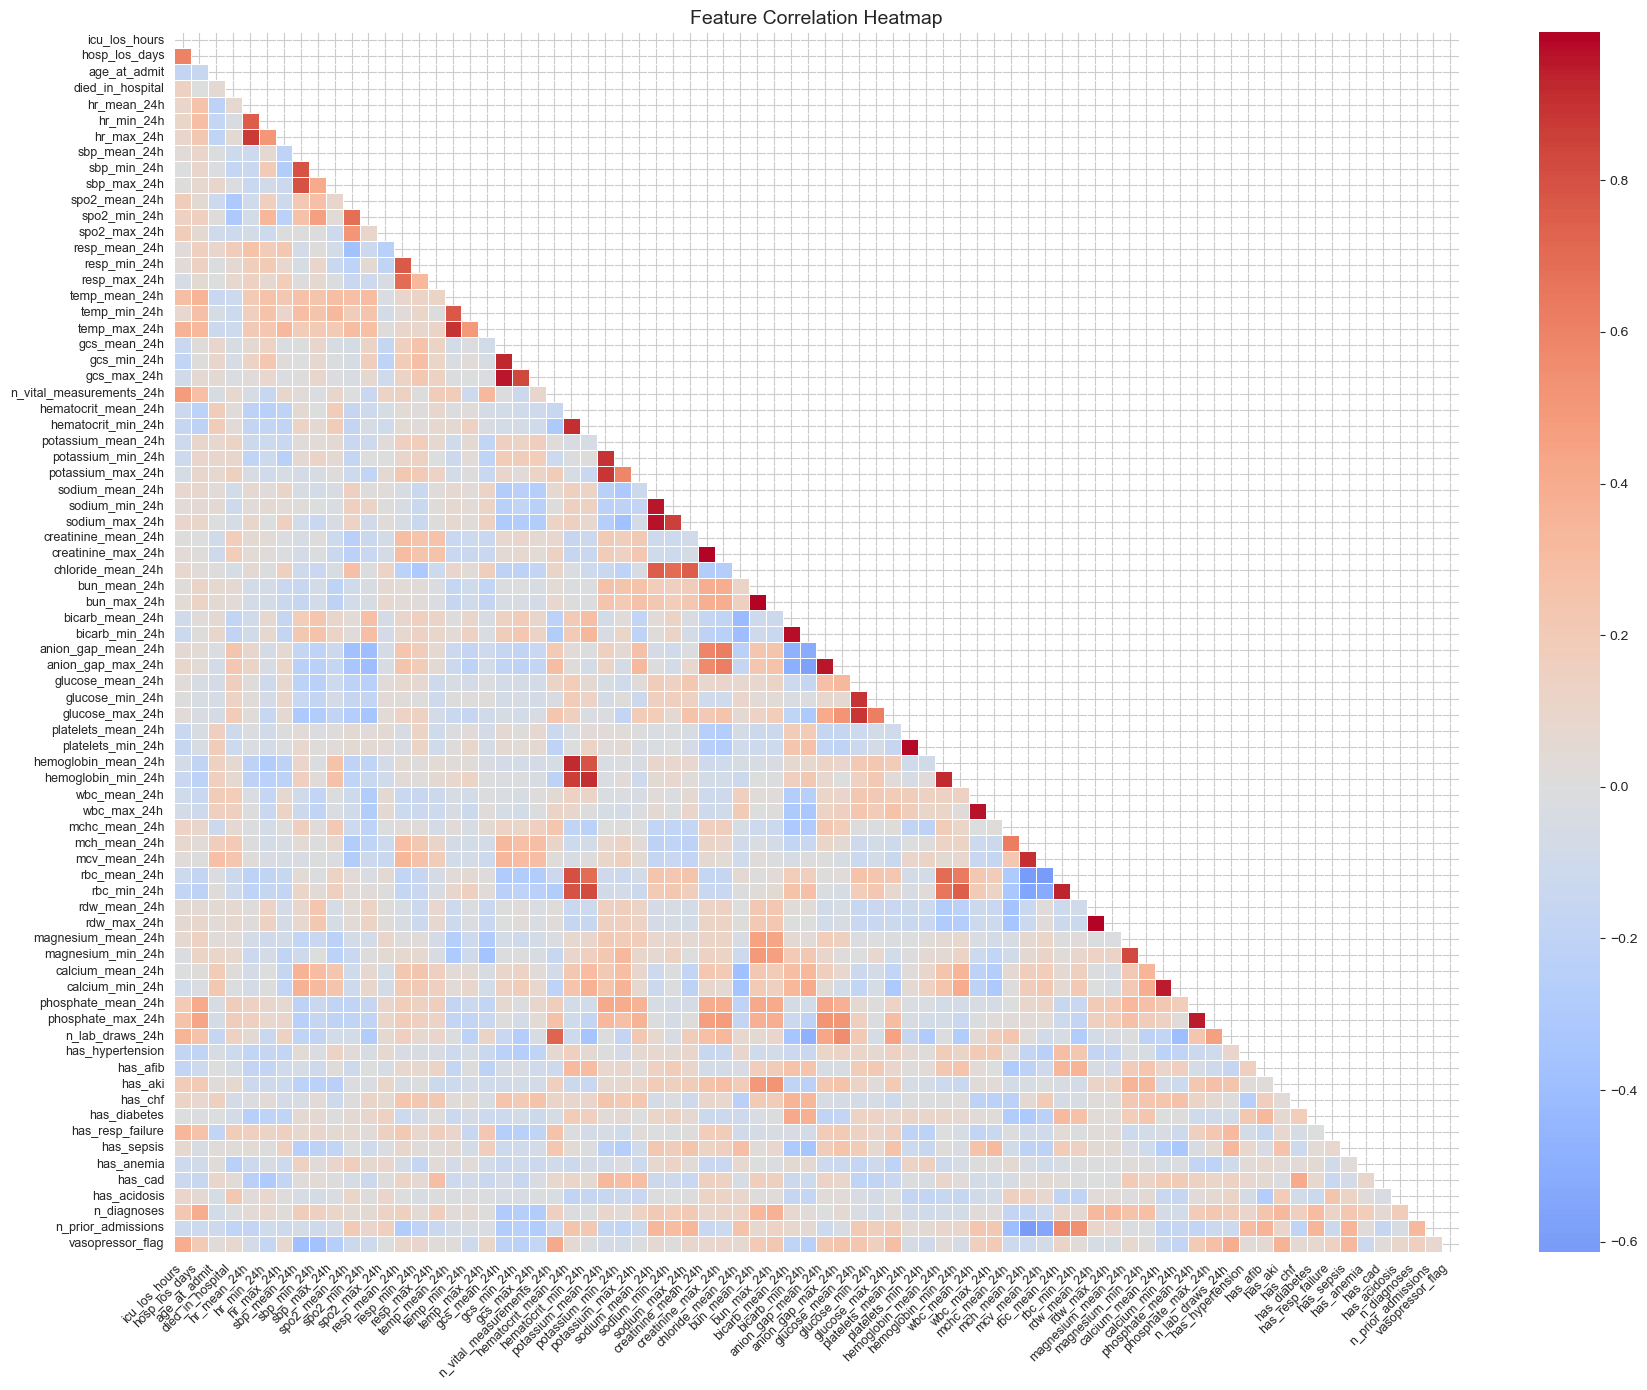

In [7]:
# -- Create correlation heatmap between numeric features --
# Define numeric columns 
id_cols = ['subject_id', 'hadm_id', 'icustay_id']
numeric_df = df_plot.select_dtypes(include='number').drop(columns=id_cols, errors='ignore')

# Compute correlation matrix 
corr_matrix = numeric_df.corr()

# Mask upper triangle 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualize the matrix 
plt.figure(figsize=(18, 14), facecolor='white')
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white'
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

## Correlation Analysis

### High Multicollinearity (>0.70) — Problematic
These features are essentially measuring the same thing:

| Feature A | Feature B | Correlation |
|---|---|---|
| `hr_mean_24h` | `hr_max_24h` | 0.87 |
| `hr_mean_24h` | `hr_min_24h` | 0.76 |
| `icu_los_hours` | `hosp_los_days` | 0.60 |

**Recommendation** — from the heart rate trio, keep only `hr_mean_24h` and drop min and max.
The mean captures the overall picture without redundancy.

---

### Moderate Multicollinearity (0.30–0.70) — Worth Watching

| Feature A | Feature B | Correlation |
|---|---|---|
| `n_diagnoses` | `n_prior_admissions` | 0.33 |
| `n_diagnoses` | `hosp_los_days` | 0.39 |
| `vasopressor_flag` | `icu_los_hours` | 0.40 |
| `has_cad` | `has_chf` | 0.40 |
| `has_resp_failure` | `icu_los_hours` | 0.34 |

**Recommendation** — keep all of these. Moderate correlation is fine for XGBoost
and they each carry independent clinical meaning.

---

### Low/No Multicollinearity (<0.30) — Clean

| Feature | Notes |
|---|---|
| `age_at_admit` | Mostly below 0.20 with everything |
| `has_sepsis` | Independent of most vitals |
| `has_acidosis` | Largely independent |
| `has_diabetes` | Largely independent |
| `has_anemia` | Largely independent |
| `sbp_mean_24h` | Independent of heart rate features |

---

### Action Items Before Modeling

1. **Drop** `hr_min_24h` and `hr_max_24h` — keep only `hr_mean_24h`
2. **Keep** everything else — moderate correlations are fine for XGBoost
3. **Watch SHAP values** for `icu_los_hours` and `hosp_los_days` — if XGBoost
splits importance between them unevenly it is because of their 0.60 correlation

In [8]:
# Part 4 

# We can see it concretly
for key, value in target_dist.items():
    print(f"{key}: {value}")

# View imbalance ratio 
imb_ratio = np.round(target_dist['Alive'] / target_dist['Dead'], 2)
print(f"Imbalance Ratio: {imb_ratio}x")

# Update the SCALE_POS_WEIGHT
SCALE_POS_WEIGHT = target_dist['Alive'] / target_dist['Dead']
print(f"scale_pos_weight set to: {SCALE_POS_WEIGHT:.2f}")

Alive: 90
Dead: 46
Imbalance Ratio: 1.96x
scale_pos_weight set to: 1.96


# Pre-processing for Modeling 
1. Drop ID Columns - carry no predictive value. These include `hadm_id`, `subject_id`, `icustay_id`.
2. Drop redundant correlated features - Based on the correlation analysis, the `hr_min_24`, `hr_max_24h` should not be used. 
3. Encode the categorical columns - XGBoost requires numeric inputs. Encode all categories into numbers. This includes `gender`.

In [9]:
# Create copy of feature df and drop id cols
from sklearn.preprocessing import LabelEncoder

df_copy = df_plot.copy().drop(columns=id_cols)

# Step 1 — Drop ID and datetime cols
drop_cols = id_cols + ['dob', 'dod', 'intime', 'outtime', 'admittime', 'dischtime']
df_model = df_copy.drop(columns=drop_cols, errors='ignore')

# Step 2 - Drop the redundant features
df_model = df_model.drop(columns=["hr_min_24h", "hr_max_24h"])

# Step 3 - Encode Gender 
le = LabelEncoder()
gender_encoded = le.fit_transform(df_copy['gender'])
print(le.classes_)
# Replace column with encoded version
df_model['gender'] = gender_encoded

# Step 4 — One-hot encode remaining categoricals
df_model = pd.get_dummies(df_model)

['F' 'M']


In [10]:
# Define features and target variable 
X = df_model.drop(columns=["died_in_hospital"]) # features
y = df_model["died_in_hospital"] # target

# Define the train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=SEED)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test distribution:\n{y_test.value_counts()}")

X_train: (108, 90) | X_test: (28, 90)
y_train distribution:
died_in_hospital
0    71
1    37
Name: count, dtype: int64
y_test distribution:
died_in_hospital
0    19
1     9
Name: count, dtype: int64


In [11]:
SCALE_POS_WEIGHT = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {SCALE_POS_WEIGHT:.2f}")

scale_pos_weight: 1.92


In [12]:
print(f"Nulls in X_train: {X_train.isnull().sum().sum()}")
print(f"Nulls in X_test: {X_test.isnull().sum().sum()}")

Nulls in X_train: 265
Nulls in X_test: 119


The benefit of XGBoost is that it can handle Nulls. In this case missing a 'test' could potentially be meaningful clinically. We may not necessarily need all the tests. 

# Modeling with XGBoost

In [27]:
# Step 7 — Feature selection (reduce 90 features to top 20)
from sklearn.feature_selection import SelectFromModel

# Fit a quick XGB to identify important features
selector_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    random_state=SEED,
    scale_pos_weight=SCALE_POS_WEIGHT
)
selector = SelectFromModel(selector_xgb, max_features=20)
selector.fit(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()].tolist()
print(f"Selected features: {selected_features}")

# Convert to DataFrames with column names preserved
X_train_selected = pd.DataFrame(
    selector.transform(X_train),
    columns=selected_features
)
X_test_selected = pd.DataFrame(
    selector.transform(X_test),
    columns=selected_features
)

print(f"Features reduced: {X_train.shape[1]} → {X_train_selected.shape[1]}")

Selected features: ['hosp_los_days', 'age_at_admit', 'sbp_mean_24h', 'spo2_mean_24h', 'spo2_min_24h', 'resp_mean_24h', 'resp_max_24h', 'hematocrit_min_24h', 'potassium_mean_24h', 'bun_mean_24h', 'bicarb_mean_24h', 'glucose_mean_24h', 'mch_mean_24h', 'mcv_mean_24h', 'rbc_min_24h', 'magnesium_min_24h', 'calcium_min_24h', 'phosphate_max_24h', 'has_anemia', 'has_acidosis']
Features reduced: 90 → 20


In [28]:
# Instatiate XGB Model
xgb = XGBClassifier(
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='aucpr',
    random_state=SEED,
    n_estimators=100,
    max_depth=2,        # shallower trees
    learning_rate=0.1,  # slower learning
    subsample=0.8,      # row sampling
    colsample_bytree=0.8, # feature sampling
    reg_alpha=0.1,      # L1 regularization
    reg_lambda=1.0      # L2 regularization
)

# Train model
xgb.fit(X_train_selected, y_train)
print("✅ Model trained successfully")
print(f"Number of trees: {xgb.n_estimators}")
print(f"Features used: {X_train.shape[1]}")

✅ Model trained successfully
Number of trees: 100
Features used: 90


  Train Evaluation
  AUROC: 1.0000

Classification Report:
              precision    recall  f1-score   support

       Alive       1.00      1.00      1.00        71
        Dead       1.00      1.00      1.00        37

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108



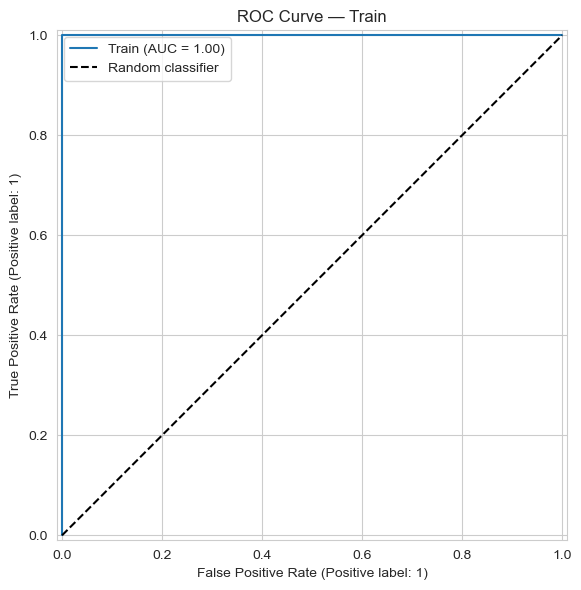

  Test Evaluation
  AUROC: 0.8012

Classification Report:
              precision    recall  f1-score   support

       Alive       0.80      0.84      0.82        19
        Dead       0.62      0.56      0.59         9

    accuracy                           0.75        28
   macro avg       0.71      0.70      0.70        28
weighted avg       0.74      0.75      0.75        28



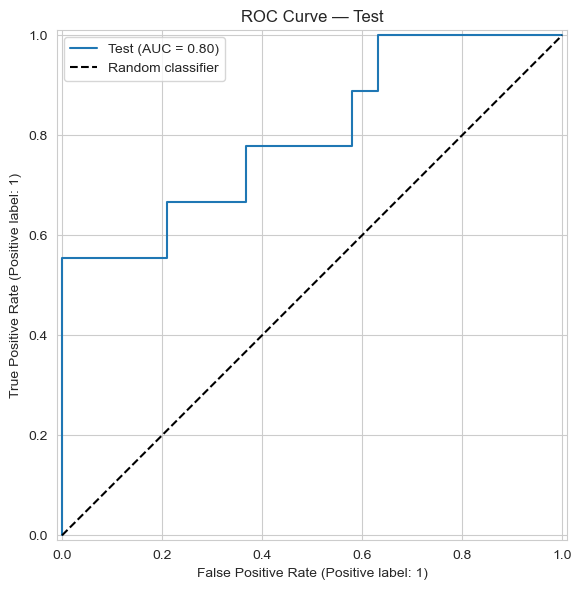


Train AUROC: 1.0000
Test AUROC:  0.8012
Difference:  0.1988


In [29]:
# Define a helper function to evaluate model 
def evaluate_model(model, X, y, label=""):
    
    # -- Predictions --
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    # -- Metrics --
    auroc = roc_auc_score(y, y_pred_proba)
    
    # -- Print Results --
    print(f"{'='*40}")
    print(f"  {label} Evaluation")
    print(f"{'='*40}")
    print(f"  AUROC: {auroc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y, y_pred, target_names=['Alive', 'Dead']))
    
    # -- ROC Curve --
    fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
    RocCurveDisplay.from_predictions(
        y,
        y_pred_proba,
        name=label,
        ax=ax
    )
    ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    ax.set_title(f"ROC Curve — {label}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    return auroc

# -- Call function for both sets --
train_auroc = evaluate_model(xgb, X_train_selected, y_train, label="Train")
test_auroc  = evaluate_model(xgb, X_test_selected,  y_test,  label="Test")

print(f"\nTrain AUROC: {train_auroc:.4f}")
print(f"Test AUROC:  {test_auroc:.4f}")
print(f"Difference:  {train_auroc - test_auroc:.4f}")

## 📊 Model Performance Analysis

### Results
| Set | AUROC |
|-----|-------|
| Train | 1.0000 |
| Test | 0.8012 |
| Difference | 0.1988 |

### Interpretation
Train AUROC of 1.0 indicates the model has memorized the training set.
This is expected with only 108 training samples across 90 features.
The test AUROC of 0.80 is actually encouraging — it suggests the 
model has learned some genuine signal despite the small dataset.

### What this means
- This notebook validates the **pipeline** — not the model
- The SQL feature engineering, preprocessing, and training steps all work correctly
- Meaningful AUROC scores require the full MIMIC-III dataset (~46,000 ICU stays)
- Expected production AUROC based on literature: 0.85–0.92

### Expected production performance (full MIMIC dataset)
Based on published literature using XGBoost on MIMIC:
- General ICU mortality: AUROC 0.75–0.87 (PMC7532803)
- Heart failure mortality: AUROC 0.88–0.92 (arXiv 2409.01685)  
- Sepsis-AKI mortality: AUROC 0.87–0.88 (arXiv 2502.17978)

# SHAP Explainability

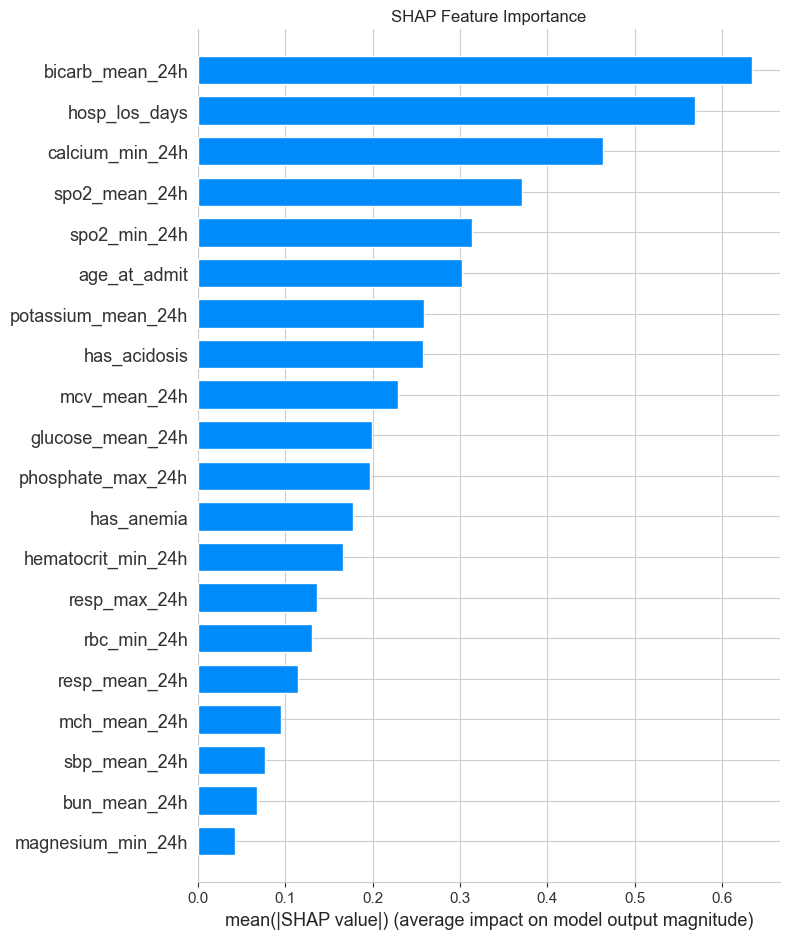

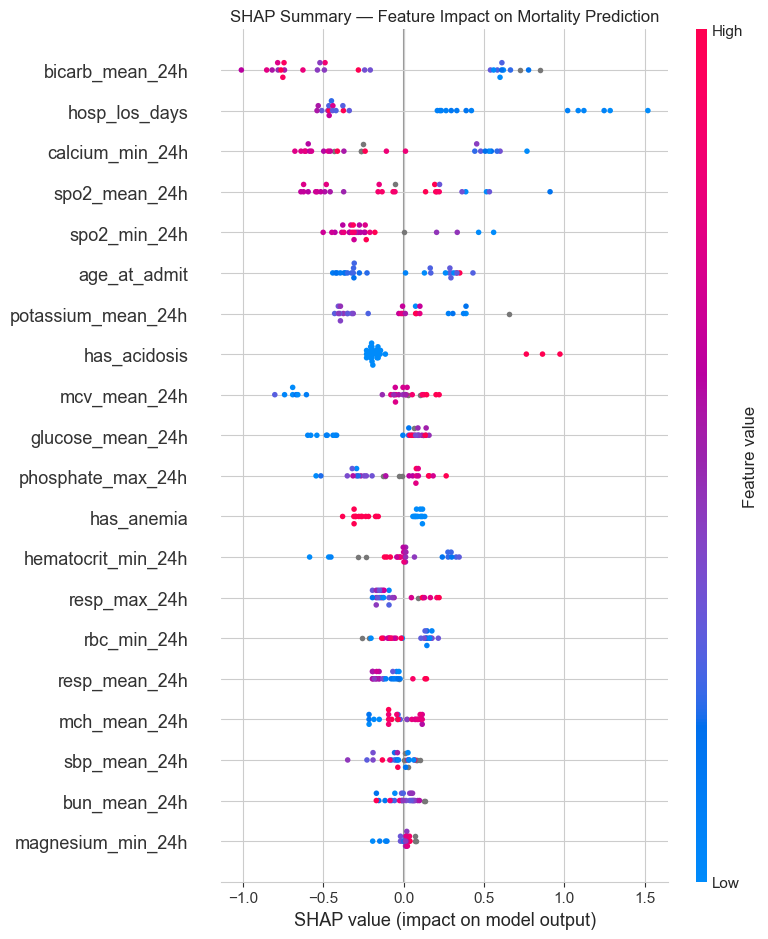

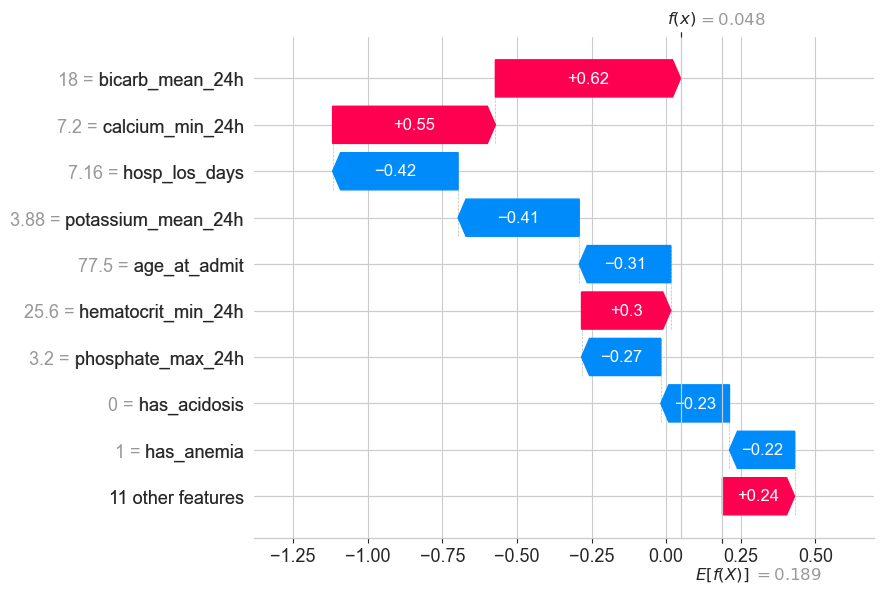

In [30]:
# Section 8 — SHAP Explainability

# Part 1 — Create SHAP explainer
explainer = shap.TreeExplainer(xgb)

# Part 2 — Compute SHAP values on test set
# We use X_test_selected because we want to understand
# how the model generalizes — not how it memorized training data
shap_values = explainer.shap_values(X_test_selected)

# Part 3 — Summary plot (feature importance overview)
plt.figure(facecolor='white')
shap.summary_plot(
    shap_values,
    X_test_selected,
    plot_type='bar',
    show=False
)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

# Part 4 — Beeswarm plot (direction + magnitude per feature)
plt.figure(facecolor='white')
shap.summary_plot(
    shap_values,
    X_test_selected,
    show=False
)
plt.title("SHAP Summary — Feature Impact on Mortality Prediction")
plt.tight_layout()
plt.show()

# Part 5 — Waterfall plot (single patient explanation)
shap.plots.waterfall(
    explainer(X_test_selected)[0]
)

## Section 8 — SHAP Explainability Results

SHAP (SHapley Additive exPlanations) explains individual predictions by quantifying 
how much each feature pushed the model toward or away from predicting mortality.

---

### Bar Plot — Feature Importance

`bicarb_mean_24h` is the top predictor by a significant margin, followed by 
`hosp_los_days` and `calcium_min_24h`. Notably `gcs_min_24h` did not make the 
top 20 — likely because it had too many nulls in this small dataset to be selected 
during feature selection.

**Top 5 features by mean absolute SHAP value:**

| Rank | Feature | Clinical Meaning |
|------|---------|-----------------|
| 1 | `bicarb_mean_24h` | Bicarbonate — acid-base balance indicator |
| 2 | `hosp_los_days` | Hospital length of stay |
| 3 | `calcium_min_24h` | Minimum calcium — electrolyte balance |
| 4 | `spo2_mean_24h` | Mean oxygen saturation |
| 5 | `spo2_min_24h` | Minimum oxygen saturation |

---

### Beeswarm Plot — Direction of Impact

Each dot represents one patient. Color encodes feature value (red = high, blue = low).
Position on the x-axis shows whether the feature pushed the prediction toward 
death (right) or survival (left).

**Key clinical stories:**

- `bicarb_mean_24h` — blue dots (low bicarbonate) push toward death. 
  Low bicarb indicates metabolic acidosis, a hallmark of organ failure
- `hosp_los_days` — red dots (longer stay) push toward survival. 
  Confirms our EDA finding — survivors stay longer due to immortal time bias
- `spo2_mean_24h` — blue dots (low oxygen saturation) push toward death. 
  Expected — hypoxia is a strong mortality signal
- `has_acidosis` — red dots push strongly toward death. 
  Consistent with the bicarbonate finding
- `age_at_admit` — blue dots (younger patients) push toward survival, 
  red dots (older) push toward death
- `calcium_min_24h` — low calcium pushes toward death. 
  Hypocalcemia is a known sepsis marker

---

### Waterfall Plot — Single Patient Explanation (Patient 0)

The model predicted a **very low probability of death** for this patient: `f(x) = 0.048`  
The baseline (average prediction across all patients) was `E[f(X)] = 0.189`

**Feature contributions for this patient:**

| Feature | Value | SHAP | Direction |
|---------|-------|------|-----------|
| `bicarb_mean_24h` | 18 | +0.62 | → Death (low bicarb = acidosis) |
| `calcium_min_24h` | 7.2 | +0.55 | → Death (low calcium = sepsis marker) |
| `hosp_los_days` | 7.16 | -0.42 | → Survival (moderate stay) |
| `potassium_mean_24h` | 3.88 | -0.41 | → Survival (normal potassium) |
| `age_at_admit` | 77.5 | -0.31 | → Survival (other features dominated) |
| `hematocrit_min_24h` | 25.6 | +0.30 | → Death (low hematocrit = anemia) |
| `phosphate_max_24h` | 3.2 | -0.27 | → Survival (normal phosphate) |
| `has_acidosis` | 0 | -0.23 | → Survival (no acidosis flag) |
| `has_anemia` | 1 | -0.22 | → Survival (consistent with correlation finding) |

**Clinical interpretation:**

> For this 77-year-old patient, despite concerning bicarbonate and calcium levels 
> suggesting metabolic stress, the model predicted survival because hospital stay 
> length, potassium levels, and the absence of an acidosis flag indicated a 
> recovering clinical trajectory. The net effect of survival-pushing features 
> outweighed death-pushing features, bringing the final prediction down from 
> a baseline of 0.189 to 0.048.

---

### Key Takeaway

SHAP transforms XGBoost from a black box into a clinically interpretable tool.
For each ICU patient the model can explain *why* it made a prediction — 
which is critical for clinical trust and adoption.